In [1]:
# I want to do a simultaneous evaluation of the POIs and compute the correlation matrix
import uproot
import os
import glob
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
import mplhep as hep
import seaborn as sns
import ROOT
import pandas as pd
from scipy import stats
import numpy as np
from scipy.optimize import minimize, curve_fit
from scipy.stats import moment
import json
from itertools import combinations  

In [2]:
# Importing translation dictionary
translationFilePath = "/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/translation.json"
with open(translationFilePath) as translationFile:
    translation = json.load(translationFile)

In [3]:
test = uproot.open("/t3home/niharrin/devel/pnfs/ntuples/midRun3/samples/2025_10_14_intermediate/finalfits_postBPix/PTH_allReplica/Combine/runFits_PTH/toyFit/toy_0/higgsCombineToyFit.MultiDimFit.mH125.38.root")

In [4]:
poi_list = ["r_PTH_0p0_15p0", "r_PTH_15p0_30p0", "r_PTH_30p0_45p0", "r_PTH_45p0_80p0", "r_PTH_80p0_120p0", "r_PTH_120p0_200p0", "r_PTH_200p0_350p0", "r_PTH_350p0_10000p0"]

indicator = 0
for i, poi in enumerate(poi_list):
    current_list = list(test["limit"][poi].array())
    central_value = current_list[indicator]
    sigma_minus = current_list[indicator+1]
    sigma_plus = current_list[indicator+2]
    indicator += 2
    
    print(f"POI: {poi}, Central Value: {central_value}, -1 Sigma: {sigma_minus}, +1 Sigma: {sigma_plus}")
print(list(test["limit"]["r_PTH_0p0_15p0"].array()))
print(list(test["limit"]["r_PTH_15p0_30p0"].array()))
print(list(test["limit"]["r_PTH_30p0_45p0"].array()))
print(list(test["limit"]["r_PTH_45p0_80p0"].array()))
print(list(test["limit"]["r_PTH_80p0_120p0"].array()))
print(list(test["limit"]["r_PTH_120p0_200p0"].array()))
print(list(test["limit"]["r_PTH_200p0_350p0"].array()))
print(list(test["limit"]["r_PTH_350p0_10000p0"].array()))

POI: r_PTH_0p0_15p0, Central Value: -0.21043013036251068, -1 Sigma: -0.9824673533439636, +1 Sigma: 0.5548661351203918
POI: r_PTH_15p0_30p0, Central Value: 0.3405541181564331, -1 Sigma: -0.605441153049469, +1 Sigma: 1.472805380821228
POI: r_PTH_30p0_45p0, Central Value: 1.215387225151062, -1 Sigma: 0.030711013823747635, +1 Sigma: 2.4844107627868652
POI: r_PTH_45p0_80p0, Central Value: 1.9347655773162842, -1 Sigma: 0.9735762476921082, +1 Sigma: 2.907226324081421
POI: r_PTH_80p0_120p0, Central Value: -0.48027554154396057, -1 Sigma: -1.7303826808929443, +1 Sigma: 0.8073716759681702
POI: r_PTH_120p0_200p0, Central Value: 0.3653924763202667, -1 Sigma: -0.7119255661964417, +1 Sigma: 1.5007058382034302
POI: r_PTH_200p0_350p0, Central Value: 3.422567129135132, -1 Sigma: 1.747252345085144, +1 Sigma: 16.0
POI: r_PTH_350p0_10000p0, Central Value: -15.999996185302734, -1 Sigma: -16.0, +1 Sigma: -12.449893951416016
[-0.21043013, -0.98246735, 0.55486614, -0.21043013, -0.21043013, -0.21043013, -0.2104

In [5]:
# Do everything untrimmed, i.e., include failed fits as -999. Then combine every considered variable into a big json file.
# Should we do a trimming??
def pois_untrimmed(toyDir_, poi_list_):
    pois = {}

    for current_poi in poi_list_:

        pois[current_poi] = []

    for i in range(len(glob.glob(os.path.join(toyDir_, "toy_*")))):

        if i%100==0:
            print(f"Processing fit_{i}")

        try:
            # current_root_files = uproot.open(f"{toyDir_}/toy_{i}/higgsCombineToyFit.MultiDimFit.mH125.38.root")
            current_root_files = uproot.open(f"{toyDir_}/toy_{i}/higgsCombineToyFit.MultiDimFit.mH125.root")
        except:
            print(f"Skipping fit_{i}: Required scan files not found")
            for current_poi in poi_list_:
                pois[current_poi].append([-999.0, -999.0, -999.0])
            continue

        indicator = 0
        for j, current_poi in enumerate(poi_list_):

            try: 
                current_tree = current_root_files["limit"]
            except:
                print(f"Skipping fit_{i}: Tree 'limit' not found in ROOT file")
                pois[current_poi].append([-999.0, -999.0, -999.0])
                continue

            current_limit_values = list(current_tree[current_poi].array())

            try:
                if current_limit_values[0]<-4:
                    print("Value out of boundary", current_limit_values[0], i)
            except:
                if j == 0:
                    print("Empty ROOT file for bootstrap: ", i)
                pois[current_poi].append([-999.0, -999.0, -999.0])
                continue

            if len(current_limit_values) == 1:
                pois[current_poi].append([-999.0, -999.0, -999.0])
                continue

            # print(i, current_limit_values)
            pois[current_poi].append([float(current_limit_values[indicator]), float(current_limit_values[indicator+1]), float(current_limit_values[indicator+2])])
            indicator += 2
    return pois

In [6]:
def gaus(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2))

def create_pull_plots(variable_, toyDir_, pois_untrimmed_, poi_list_, subfolder_, extra_name=""):

    # Now we have to fit a gaussian core to all the categories to get the values where we cut. z is the number of standard deviations we want to cut away
    trimming_value_left = 0
    trimming_value_right = 0
    largest_sigma = 0
    mu_to_largest_sigma = 0
    z = 4 # 4
    
    pois_central = {}
    # pois_sigma_minus = {}
    # pois_sigma_plus = {}
    pois_sigma = {}
    
    for i, current_poi in enumerate(poi_list_):
        pois_central[current_poi] = []
        # pois_sigma_minus[current_poi] = []
        # pois_sigma_plus[current_poi] = []
        pois_sigma[current_poi] = []
    
    for i, current_poi in enumerate(poi_list_):
        for current_value in pois_untrimmed_[current_poi]:
            pois_central[current_poi].append(current_value[0])
            # pois_sigma_minus[current_poi].append(current_value[1])
            # pois_sigma_plus[current_poi].append(current_value[2])
            
            if 1 <= current_value[0]:
                # sigma_minus
                pois_sigma[current_poi].append(current_value[2])
            else:
                # sigma_plus
                pois_sigma[current_poi].append(current_value[1])
                
    for i, current_poi in enumerate(poi_list_):
        r = np.array(pois_central[current_poi])
        r = r[r > -998.0]
        mean = np.mean(r)
        s = np.array(pois_sigma[current_poi])
        s = s[s > -998.0]
        s_mean = np.mean(s)
        # r = r[r < 5.0]
        
        bins = 60 # 30
        
        counts, bin_edges = np.histogram(r, bins=bins, density=False)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        popt, _ = curve_fit(gaus, bin_centers, counts, p0=[1, mean, s_mean], maxfev=10000)
        amp_fit, mu_fit, sigma_fit = popt
        
        # Define the pull
        
        pull = []
        for i, val in enumerate(r):
            pull.append((val - 1.0) / s[i])
            
        # pull = (r - 1.0) / s
        mean_pull = np.mean(pull)
        s_pull = np.std(pull)
        skewness_pull = stats.skew(pull)
        kurtosis_pull = stats.kurtosis(pull)

        # Fit for the pulls
        counts_pull, bin_edges_pull = np.histogram(pull, bins=bins, density=False, range=(-5, 5))
        bin_centers_pull = (bin_edges_pull[:-1] + bin_edges_pull[1:]) / 2

        popt_pull, _ = curve_fit(gaus, bin_centers_pull, counts_pull, p0=[1, 0.0, 1], maxfev=10000)
        amp_fit_pull, mu_fit_pull, sigma_fit_pull = popt_pull

        if i == 0:
            largest_sigma = sigma_fit
            mu_to_largest_sigma = mu_fit
        else:
            if (sigma_fit > largest_sigma):
                largest_sigma = sigma_fit
                mu_to_largest_sigma = mu_fit

        if (not os.path.exists(f"./Plots/{variable_}/{subfolder_}")) & (f"./Plots/{variable_}/{subfolder_}"!=""):
            os.makedirs(f"./Plots/{variable_}/{subfolder_}")
        

        plt.figure(figsize=(12, 8))
        plt.style.use(hep.style.CMS)
        hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6)
        plt.hist(r, bins=bins, density=False, alpha=0.6, label='S+B Toys') #30
        plt.plot(bin_centers, gaus(bin_centers, *popt), color='red', label='Fitted Gaussian')
        plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.2f} ± {np.std(r):.2f}')
        plt.axvline(np.median(r), color='blue', linestyle='--', label=f'Median: {np.median(r):.2f}')
        plt.axvline(1.0, color='grey', linestyle='--', label=r'$\mu=1$')
        plt.legend()
        plt.xlabel(f"{translation[f'{current_poi}']}")
        plt.ylabel(r'$N$')
        plt.savefig(f"./Plots/{variable_}/{subfolder_}/gaussian_fit_{current_poi}.png")
        plt.close()

        # Compute the pull
        plt.figure(figsize=(12, 8))

        # Get axis limits
        xlim = plt.xlim()
        ylim = plt.ylim()

        plt.style.use(hep.style.CMS)
        hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6)
        # if current_poi in ["r_PTH_0p0_15p0", "r_PTH_15p0_30p0", "r_PTH_45p0_80p0", "r_NJ_0p0_1p0"]:
        #     plt.hist(pull, bins=bins, density=False, alpha=0.6, label='Pull', range=(-2, 4)) #30
        # else:
        #     plt.hist(pull, bins=bins, density=False, alpha=0.6, label='Pull') #30
        plt.hist(pull, bins=bins, density=False, alpha=0.6, label='Pull', range=(-2, 2))
        # plt.plot(bin_centers_pull, gaus(bin_centers_pull, *popt_pull), color='red', label='Fitted Gaussian')
        plt.text(
            xlim[0] + 0.9*(xlim[1] - xlim[0]),   # 70% across the x-axis
            ylim[0] + 0.8*(ylim[1] - ylim[0]),   # 80% up the y-axis
            f'Mean: {mean_pull:.2f}\nStd Dev: {s_pull:.2f}\nSkewness: {skewness_pull:.2f}\nKurtosis: {kurtosis_pull:.2f}',
            bbox=dict(facecolor='white', alpha=0.5)
        )
        plt.xlabel(f"{translation[f'{current_poi}']}")
        plt.ylabel(r'$N$')
        plt.grid()
        plt.savefig(f"./Plots/{variable_}/{subfolder_}/pull_{current_poi}.png")
        plt.close()


In [7]:
def create_json_untrimmed_per_variable(variable_, toyDir_, poi_list_, extra_name=""):
    # Loop through all fit directories (fit_0, fit_1, etc.)
    if not os.path.exists(f'pois_untrimmed_{variable_}{extra_name}.json'):
        pois = pois_untrimmed(toyDir_, poi_list_)
        # Save the POIs to a JSON file
        with open(f'pois_untrimmed_{variable_}{extra_name}.json', 'w') as f:
            json.dump(pois, f)
    else:
        # Load the POIs from the JSON file
        with open(f'pois_untrimmed_{variable_}{extra_name}.json', 'r') as f:
            pois = json.load(f)

    return pois

In [8]:
plot_dir = "Plots"
os.makedirs(plot_dir, exist_ok=True)

In [9]:
# Load PTH toys
variable = "PTH"
# sample_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_06_12/intermediateRun3/finalfits'
# sample_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_10_14_intermediate/finalfits_postBPix'
sample_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_09_22/earlyRun3_powheg/finalfits'
main_dir = os.path.join(sample_dir, variable, "Combine", f"runFits_{variable}")
toyDir = os.path.join(main_dir, "toyFit")

poi_list = ["r_PTH_0p0_15p0", "r_PTH_15p0_30p0", "r_PTH_30p0_45p0", "r_PTH_45p0_80p0", "r_PTH_80p0_120p0", "r_PTH_120p0_200p0", "r_PTH_200p0_350p0", "r_PTH_350p0_10000p0"]

pois_untrimmed_PTH = create_json_untrimmed_per_variable(variable, toyDir, poi_list, extra_name="_pull")
pois_PTH = create_pull_plots(variable, toyDir, pois_untrimmed_PTH, poi_list, subfolder_=f"SL_{variable}")

# plot_all_individual_correlation(pois_PTH, poi_list, variable)

Processing fit_0
Value out of boundary -16.0 1
Value out of boundary -15.999996 5
Value out of boundary -15.999995 6
Value out of boundary -5.2720914 7
Value out of boundary -15.999999 10
Value out of boundary -16.0 14
Value out of boundary -15.999998 15
Value out of boundary -16.0 17
Value out of boundary -4.915546 22
Value out of boundary -4.2921886 32
Value out of boundary -7.09978 35
Value out of boundary -16.0 39
Value out of boundary -5.9618816 41
Value out of boundary -5.0984383 45
Value out of boundary -16.0 46
Value out of boundary -16.0 53
Value out of boundary -16.0 65
Value out of boundary -5.439684 67
Value out of boundary -4.880766 70
Value out of boundary -16.0 72
Value out of boundary -15.999997 87
Value out of boundary -4.161678 88
Value out of boundary -7.6703677 90
Value out of boundary -15.999999 97
Value out of boundary -16.0 98
Processing fit_100
Value out of boundary -4.258728 101
Value out of boundary -15.999999 106
Value out of boundary -7.942186 109
Value out 

In [10]:
# df_PTH = pd.DataFrame(pois_untrimmed_PTH)
# print(df_PTH[(df_PTH['r_PTH_350p0_10000p0'] > -998.0) & (df_PTH['r_PTH_350p0_10000p0'] < -15.8)]['r_PTH_350p0_10000p0'].index.tolist())

In [11]:
# Load NJ toys
variable = "NJ"

main_dir = os.path.join(sample_dir, variable, "Combine", f"runFits_{variable}")
toyDir = os.path.join(main_dir, "toyFit")

poi_list_NJ = ["r_NJ_0p0_1p0", "r_NJ_1p0_2p0", "r_NJ_2p0_3p0", "r_NJ_3p0_100p0"]

pois_untrimmed_NJ = create_json_untrimmed_per_variable(variable, toyDir, poi_list_NJ, extra_name="_pull")
pois_NJ = create_pull_plots(variable, toyDir, pois_untrimmed_NJ, poi_list_NJ, subfolder_=f"SL_{variable}")

# plot_all_individual_correlation(pois_untrimmed_NJ, poi_list_NJ, variable)

Processing fit_0
Value out of boundary -9.937969 1
Value out of boundary -4.7733617 5
Value out of boundary -6.833837 6
Value out of boundary -9.757844 8
Value out of boundary -8.929119 14
Value out of boundary -8.937887 16
Value out of boundary -9.999999 18
Value out of boundary -6.364604 19
Value out of boundary -5.4278316 21
Value out of boundary -4.2852473 23
Value out of boundary -5.6464405 31
Value out of boundary -10.0 32
Value out of boundary -6.9859033 33
Value out of boundary -7.9942327 34
Value out of boundary -4.283504 36
Value out of boundary -6.748695 38
Value out of boundary -4.9130187 47
Value out of boundary -5.5559883 48
Value out of boundary -4.1560144 50
Value out of boundary -10.0 56
Value out of boundary -10.0 58
Value out of boundary -9.999999 60
Value out of boundary -9.999928 64
Value out of boundary -6.816193 69
Value out of boundary -8.371655 70
Value out of boundary -9.999998 72
Value out of boundary -6.704415 76
Value out of boundary -9.554999 77
Value out 

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 10000.

In [10]:
df_PTH = pd.DataFrame(pois_PTH)
df_NJ = pd.DataFrame(pois_NJ)
# df_PTJ0 = pd.DataFrame(pois_PTJ0)
# df_rapidity = pd.DataFrame(pois_rapidity)


In [11]:
df_PTH_untrimmed = pd.DataFrame(pois_untrimmed_PTH)
df_NJ_untrimmed = pd.DataFrame(pois_untrimmed_NJ)
mask_pth_untrimmed = (df_PTH_untrimmed != -999).all(axis=1)
mask_nj_untrimmed = (df_NJ_untrimmed != -999).all(axis=1)
valid_rows_untrimmed = mask_pth_untrimmed & mask_nj_untrimmed
df_PTH_clean_untrimmed = df_PTH_untrimmed[valid_rows_untrimmed]
df_NJ_clean_untrimmed = df_NJ_untrimmed[valid_rows_untrimmed]

In [12]:

# --- Step 1: Identify rows WITHOUT -999 in either DataFrame ---
# # Mask for df_PTH (True = valid, False = -999)
mask_pth = (df_PTH != -999).all(axis=1)

# # Mask for df_NJ (True = valid, False = -999)
mask_nj = (df_NJ != -999).all(axis=1)

# # Mask for df_PTJ0 (True = valid, False = -999)
# mask_ptj0 = (df_PTJ0 != -999).all(axis=1)

# # Mask for df_DPhiJ0J1 (True = valid, False = -999)
# mask_DPhiJ0J1 = (df_DPhiJ0J1 != -999).all(axis=1)

# # Mask for df_rapidity (True = valid, False = -999)
# mask_rapidity = (df_rapidity != -999).all(axis=1)

# Combined mask (keep only rows valid in BOTH DataFrames)
# valid_rows = mask_pth & mask_nj & mask_ptj0 & mask_DPhiJ0J1 & mask_rapidity
valid_rows = mask_pth & mask_nj

# --- Step 2: Filter DataFrames ---
df_PTH_clean = df_PTH[valid_rows]
df_NJ_clean = df_NJ[valid_rows]
# df_PTJ0_clean = df_PTJ0[valid_rows]
# df_DPhiJ0J1_clean = df_DPhiJ0J1[valid_rows]
# df_rapidity_clean = df_rapidity[valid_rows]

# --- Step 3: Compute Correlation Matrix ---
# Combine columns (now aligned and cleaned)
# df_combined = pd.concat([df_PTH_clean, df_DPhiJ0J1_clean, df_NJ_clean, df_PTJ0_clean, df_rapidity_clean], axis=1)
df_combined = pd.concat([df_PTH_clean, df_NJ_clean], axis=1)
# df_combined = pd.concat([df_PTH_clean, df_PTJ0_clean, df_NJ_clean], axis=1)

# Calculate full correlation matrix
corr_matrix = df_combined.corr()

# # Extract cross-correlations (PTH vs. NJ bins)
# pth_cols = df_PTH.columns
# nj_cols = df_NJ.columns
# ptj0_cols = df_PTJ0.columns
# print(ptj0_cols)
# cross_corr = corr_matrix.loc[pth_cols, nj_cols, ptj0_cols]

# print("Correlation Matrix (Excluding Rows with -999):")
# print(cross_corr)

In [13]:
plt.figure(figsize=(12, 10))
plt.scatter(df_PTH_clean["r_PTH_0p0_15p0"], df_NJ_clean["r_NJ_0p0_1p0"])
plt.show()
print(df_PTH_clean["r_PTH_0p0_15p0"].corr(df_NJ_clean["r_NJ_0p0_1p0"]))


KeyError: 'r_PTH_0p0_15p0'

<Figure size 1200x1000 with 0 Axes>

In [15]:
# 1️⃣ Define your stops and RGB values
stops = [0.0, 0.5, 1.0]
red   = [0.992, 1.0, 0.110]
green = [0.749, 1.0, 0.196]
blue  = [0.106, 1.0, 0.867]

# 2️⃣ Build the color dictionary
cdict = {
    'red':   [(stops[i], red[i], red[i]) for i in range(len(stops))],
    'green': [(stops[i], green[i], green[i]) for i in range(len(stops))],
    'blue':  [(stops[i], blue[i], blue[i]) for i in range(len(stops))]
}

# 3️⃣ Create the colormap
custom_cmap = LinearSegmentedColormap('gradient_8289', cdict)

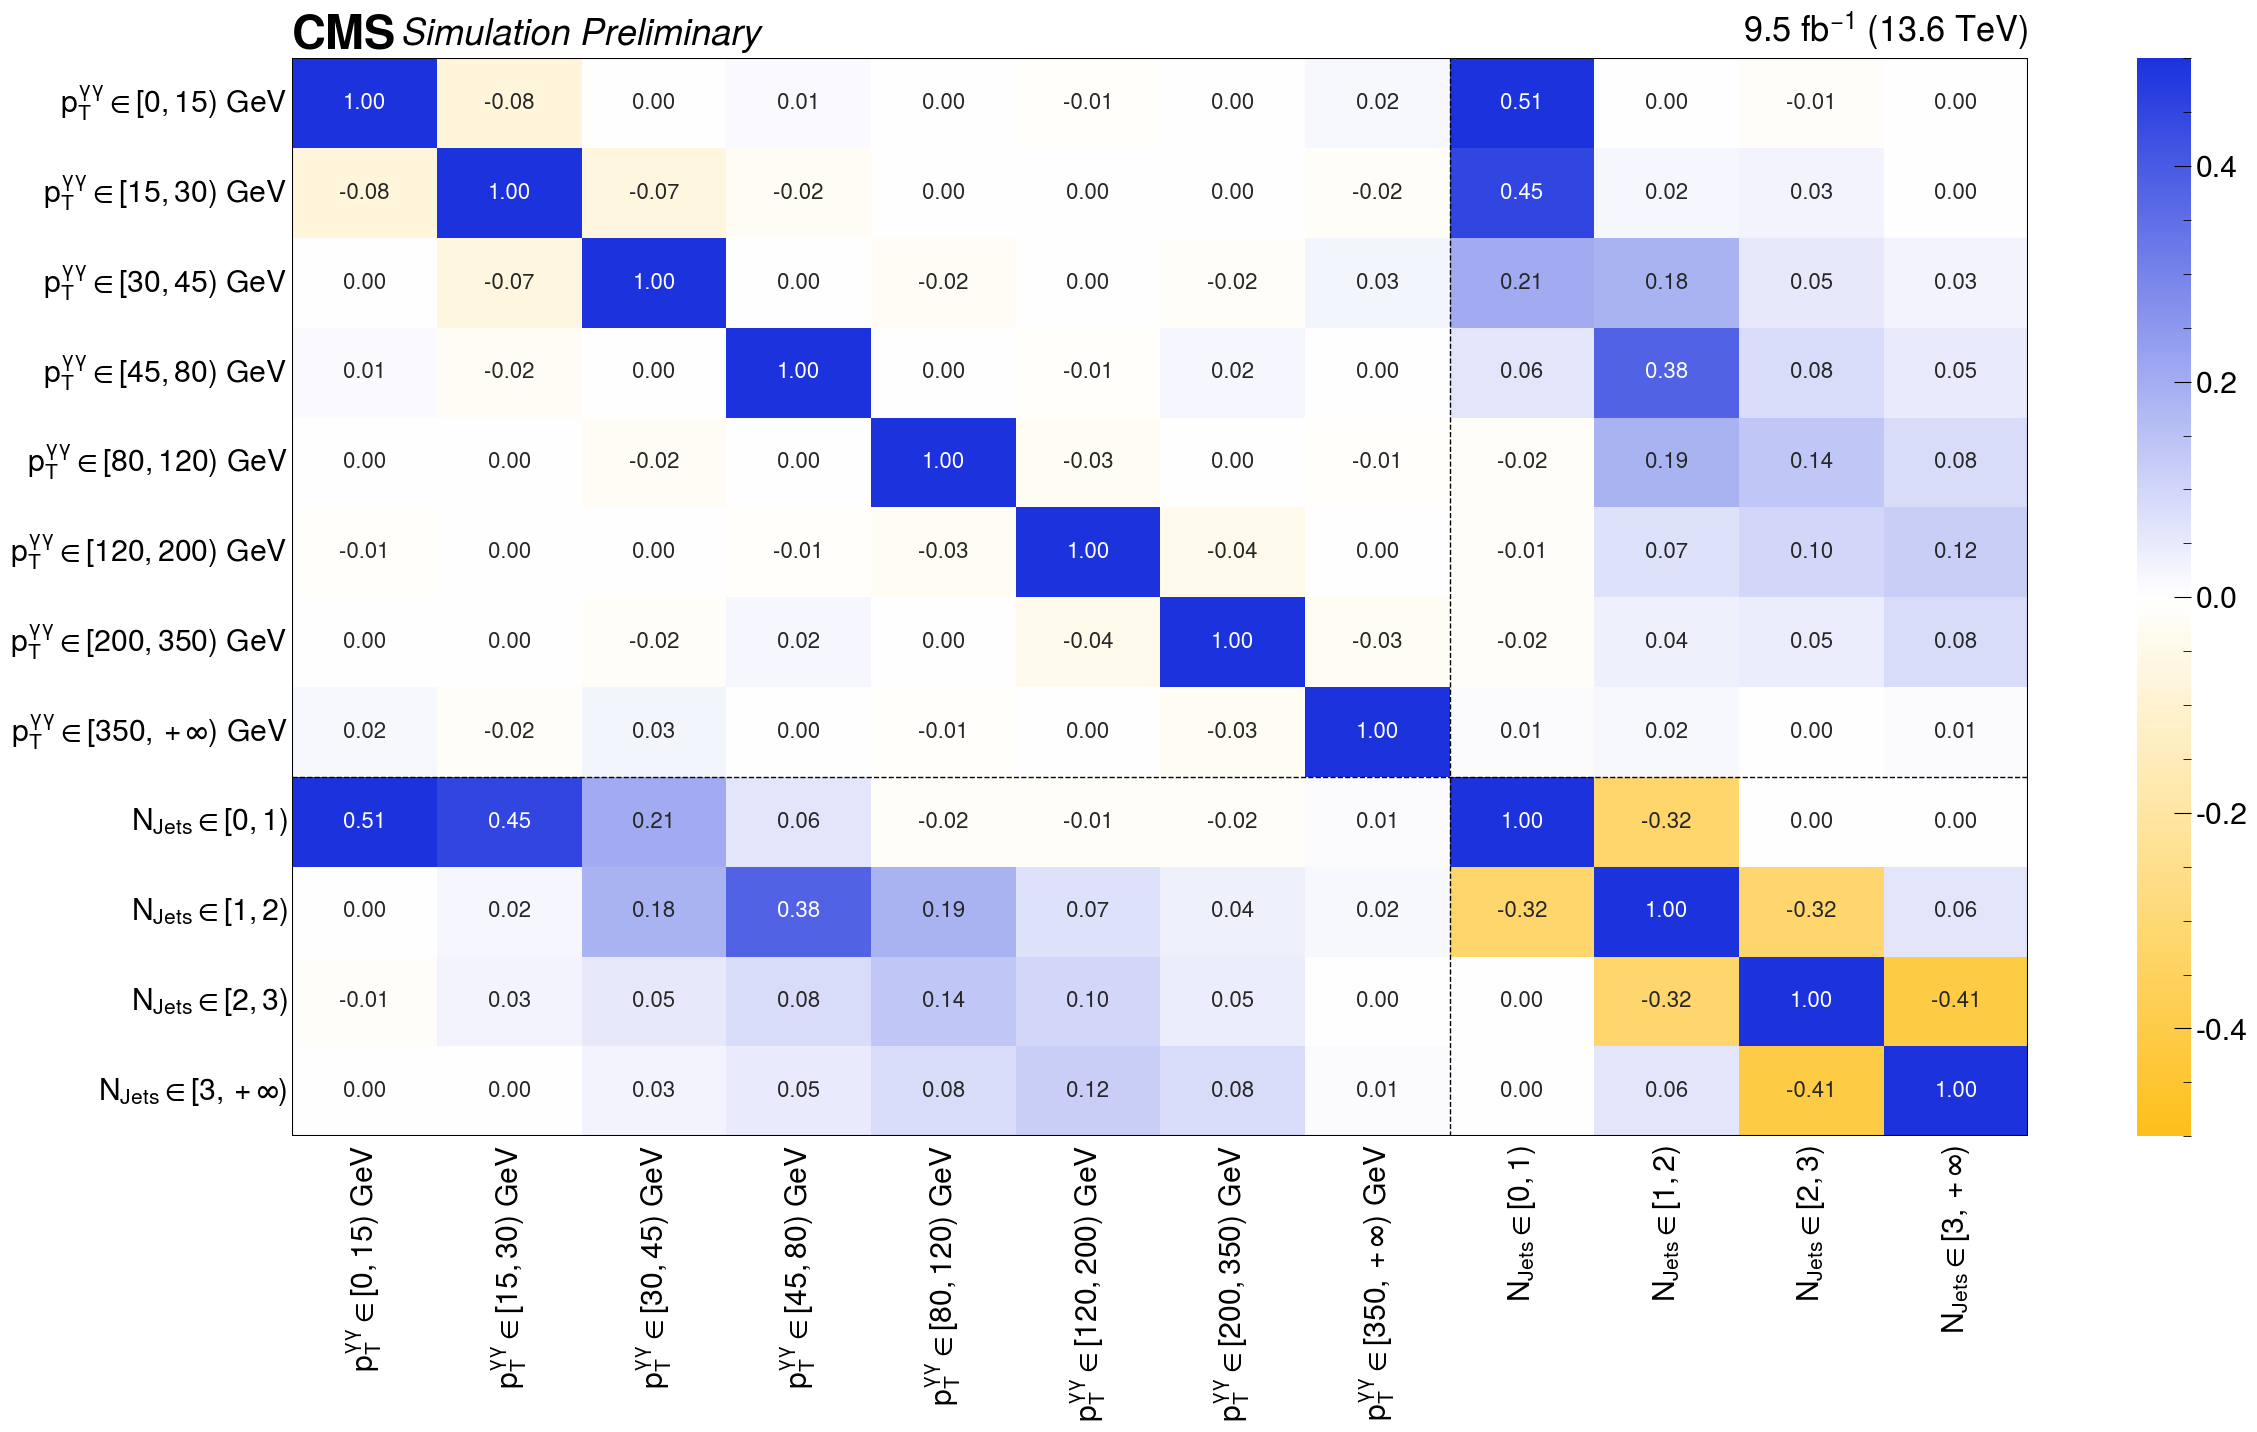

In [16]:
modified_corr_matrix = corr_matrix.copy()
modified_corr_matrix = modified_corr_matrix.where(abs(modified_corr_matrix) >= 0.01, 0)  # Set values greater than 0.1 to 0

modified_corr_matrix = modified_corr_matrix.rename(index=translation, columns=translation)

plt.figure(figsize=(28, 14))
plt.style.use(hep.style.CMS)
hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6)
ax = sns.heatmap(modified_corr_matrix, annot=True, cmap=custom_cmap, vmin=-0.5, vmax=0.5, annot_kws={"size": 16}, linewidths=0.0, linecolor='black', fmt=".2f")

ax.tick_params(
    axis='both',      # apply to both axes
    which='both',     # apply to both major and minor ticks
    bottom=False,     # remove bottom ticks
    top=False,        # remove top ticks
    left=False,       # remove left ticks
    right=False,      # remove right ticks
    labelbottom=True, # keep labels if you want
    labelleft=True    # keep labels if you want
)

# Get the number of rows and columns
n_rows, n_cols = modified_corr_matrix.shape

# Add rectangle around the whole heatmap to complete the outer box
rect = Rectangle(
    (0, 0),          # bottom left corner
    width=n_cols,    # number of columns
    height=n_rows,   # number of rows
    fill=False,      # no fill, just the edge
    edgecolor='black',
    linewidth=1.5
)
ax.add_patch(rect)

# Define group boundaries (between variable blocks)
group_boundaries = [8, 12, 17, 23]  # Example indices between variable blocks # 8, 14, 18, 23

# Draw thick lines between groups
for boundary in group_boundaries:
    ax.axhline(boundary, color='black', linewidth=1, linestyle='--')
    ax.axvline(boundary, color='black', linewidth=1, linestyle='--')

plt.savefig(os.path.join(plot_dir, "correlation_matrix.pdf"), bbox_inches='tight')
plt.savefig(os.path.join(plot_dir, "correlation_matrix.png"), bbox_inches='tight')

# plt.close()


In [18]:
def plot_matrix(matrix, boundary, filename):
    plt.figure(figsize=(14, 8))
    plt.style.use(hep.style.CMS)
    hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6)
    ax = sns.heatmap(matrix, annot=True, cmap=custom_cmap, vmin=-0.5, vmax=0.5, annot_kws={"size": 16}, linewidths=0.0, linecolor='black', fmt=".2f")

    ax.tick_params(
        axis='both',      # apply to both axes
        which='both',     # apply to both major and minor ticks
        bottom=False,     # remove bottom ticks
        top=False,        # remove top ticks
        left=False,       # remove left ticks
        right=False,      # remove right ticks
        labelbottom=True, # keep labels if you want
        labelleft=True    # keep labels if you want
    )

    # Get the number of rows and columns
    n_rows, n_cols = matrix.shape

    # Add rectangle around the whole heatmap to complete the outer box
    rect = Rectangle(
        (0, 0),          # bottom left corner
        width=n_cols,    # number of columns
        height=n_rows,   # number of rows
        fill=False,      # no fill, just the edge
        edgecolor='black',
        linewidth=1.5
    )
    ax.add_patch(rect)

    # Draw thick lines between groups
    ax.axhline(boundary, color='black', linewidth=1, linestyle='--')
    ax.axvline(boundary, color='black', linewidth=1, linestyle='--')

    plt.savefig(os.path.join(plot_dir, f"{filename}.pdf"), bbox_inches='tight')
    plt.savefig(os.path.join(plot_dir, f"{filename}.png"), bbox_inches='tight')


In [ ]:
# df_combined = pd.concat([df_PTH_clean, df_DPhiJ0J1_clean, df_NJ_clean, df_PTJ0_clean, df_rapidity_clean], axis=1)

df_combined_dict = {
    "PTH": df_PTH_clean,
    "DPhiJ0J1": df_DPhiJ0J1_clean,
    "NJ": df_NJ_clean,
    "PTJ0": df_PTJ0_clean,
    "rapidity": df_rapidity_clean
}

variable_names = ["PTH", "DPhiJ0J1", "NJ", "PTJ0", "rapidity"]
variable_pairs = list(combinations(variable_names, 2))

# Define group boundaries (between variable blocks)
group_boundaries = {
    "PTH": 8,
    "DPhiJ0J1": 6,
    "NJ": 4,
    "PTJ0": 5,
    "rapidity": 5
}

for i, (variable1, variable2) in enumerate(variable_pairs):
    df_combined_reduced = pd.concat([df_combined_dict[variable1], df_combined_dict[variable2]], axis=1)
    matrix = df_combined_reduced.corr()
    modified_matrix = matrix.copy()
    modified_matrix = modified_matrix.where(abs(modified_matrix) >= 0.01, 0)  # Set values greater than 0.1 to 0
    modified_matrix = modified_matrix.rename(index=translation, columns=translation)
    boundary = group_boundaries[variable1]
    filename = f"correlation_matrix_{variable1}vs{variable2}"
    plot_matrix(modified_matrix, boundary, filename)


In [ ]:
z_hat = 0.5 * np.log((1 + corr_matrix) / (1 - corr_matrix)) + (corr_matrix / (2*(len(df_combined) - 2)))
a = np.tanh(z_hat - np.sqrt(1 / (len(df_combined) - 3)))
b = np.tanh(z_hat + np.sqrt(1 / (len(df_combined) - 3)))

In [ ]:
b - corr_matrix

In [ ]:
corr_matrix - a

In [ ]:
# From Wikipedia https://en.wikipedia.org/wiki/Pearson_correlation_coefficient
np.sqrt((1 - corr_matrix**2) / (len(df_combined) - 2))

In [ ]:
# Load combine toys
combineToy_dir = "/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/CombineToy_Validation/toys"
variable = "PTH"

pois_untrimmed_combineToys = create_json_untrimmed(variable, combineToy_dir, poi_list, extra_name="_combineToys")
pois_combineToys = create_json_trimmed(variable, combineToy_dir, pois_untrimmed_combineToys, poi_list, subfolder_=f"SL_{variable}", extra_name="_combineToys")

In [ ]:
df_combine = pd.DataFrame(pois_untrimmed_combineToys)
# --- Step 1: Identify rows WITHOUT -999 in either DataFrame ---
# Mask for df_PTH (True = valid, False = -999)
mask_combine = (df_combine != -999).all(axis=1)

# --- Step 2: Filter DataFrames ---
df_combine = df_combine[mask_combine]

# Calculate full correlation matrix
corr_matrix_combine = df_combine.corr()

In [ ]:
corr_matrix_combine
sns.heatmap(corr_matrix_combine, annot=True, cmap='coolwarm', vmin=-0.1, vmax=0.1)

In [ ]:
# z = 5

In [ ]:
# z = 1

In [ ]:
# z = 2

In [ ]:
# z = 4


In [ ]:
np.corrcoef(df_combine["r_PTH_15p0_30p0"], df_combine["r_PTH_350p0_10000p0"])[0,1]

In [ ]:
df_combine = pd.DataFrame(pois_combineToys)
# --- Step 1: Identify rows WITHOUT -999 in either DataFrame ---
# Mask for df_PTH (True = valid, False = -999)
mask_combine = (df_combine != -999).all(axis=1)

# --- Step 2: Filter DataFrames ---
df_combine = df_combine[mask_combine]

# Calculate full correlation matrix
corr_matrix_combine = df_combine.corr()
np.corrcoef(df_combine["r_PTH_15p0_30p0"], df_combine["r_PTH_350p0_10000p0"])[0,1]

In [ ]:
plot_all_individual_correlation(pois_untrimmed_combineToys, poi_list, variable)

In [ ]:
df_untrimmed_combine = pd.DataFrame(pois_untrimmed_combineToys)
# --- Step 1: Identify rows WITHOUT -999 in either DataFrame ---
# Mask for df_PTH (True = valid, False = -999)
mask_combine = (df_untrimmed_combine != -999).all(axis=1)

# --- Step 2: Filter DataFrames ---
df_untrimmed_combine = df_untrimmed_combine[mask_combine]

# Calculate full correlation matrix
corr_matrix_untrimmed_combine = df_untrimmed_combine.corr()

In [ ]:
plt.figure(figsize=(18, 8))
sns.heatmap(corr_matrix_untrimmed_combine, annot=True, cmap='coolwarm', vmin=-0.1, vmax=0.1)

In [ ]:
df_untrimmed_NJ = pd.DataFrame(pois_untrimmed_NJ)
df_untrimmed_PTJ0 = pd.DataFrame(pois_untrimmed_PTJ0)

In [ ]:
df_untrimmed_NJ

In [ ]:
df_untrimmed_PTJ0